In [9]:
# Classification Problem: Heart Disease Prediction
# Models used: Random Forest Classifier & Deep Learning MLP
# In this section, I trained two models to classify whether a patient
# has heart disease (1) or not (0) based on medical features.
# Random Forest (traditional ML) provides very high performance with 
# hyperparameter tuning, while the Deep Learning (MLP) model captures
# complex nonlinear relationships. Finally, both are combined in a
# Hybrid Model to improve generalization and accuracy.

# Step 1: Import dependencies and read the dataset
import pandas as pd
from pathlib import Path

# Define the path to the dataset (CSV file stored inside the "data" folder)
DATA_PATH = Path("data/heart.csv")
# Read the heart disease dataset into a DataFrame
df = pd.read_csv(DATA_PATH)
# Display the dataset’s dimensions (rows, columns)
print(df.shape)
# Display the first few rows for an overview of the data
df.head()


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


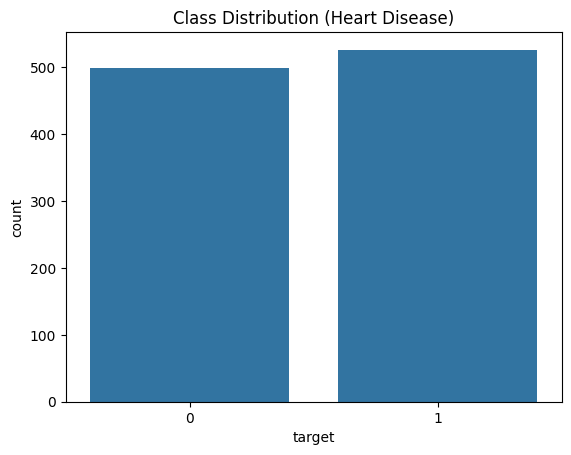

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [10]:
# Step 2: Exploratory Data Analysis (EDA)
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the class distribution (target variable = presence of heart disease)
sns.countplot(x="target", data=df)
plt.title("Class Distribution (Heart Disease)")
plt.show()

# Print class proportions (to check if dataset is balanced)
print(df["target"].value_counts(normalize=True))


In [11]:
# Step 3: Split the dataset and build preprocessing pipeline
# train_test_split divides the dataset into training and testing sets to evaluate model performance.
# Standard Scaler standardizes numerical features so they share a common scale, which helps models like neural networks converge faster.
# One Hot Encoder converts categorical variables into numeric format suitable for ML algorithms.
# Column Transfer applies different preprocessing pipelines to numeric and categorical columns in the same time.
# Pipeline combines preprocessing and model training steps into a single workflow for cleaner and more reproducible code.
# Simple Imputer fills in missing values automatically to prevent model training errors.
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features (X) and target (y)
X = df.drop("target", axis=1)
y = df["target"]

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(exclude=["int64", "float64"]).columns

# Build transformation pipeline for numerical features
# - Fill missing values with the median
# - Standardize values (zero mean, unit variance)
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Build transformation pipeline for categorical features
# - Fill missing values with the most frequent value
# - Convert to numeric using one-hot encoding
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines into a single ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# Split dataset into training (70%) and validation (30%) sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=22
)


Fitting 4 folds for each of 25 candidates, totalling 100 fits
Best RF Params: {'classifier__max_depth': 12, 'classifier__max_features': np.float64(0.32407196478065287), 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 761}
RF | Accuracy:0.9675 Precision:0.9568 Recall:0.9810 F1:0.9688


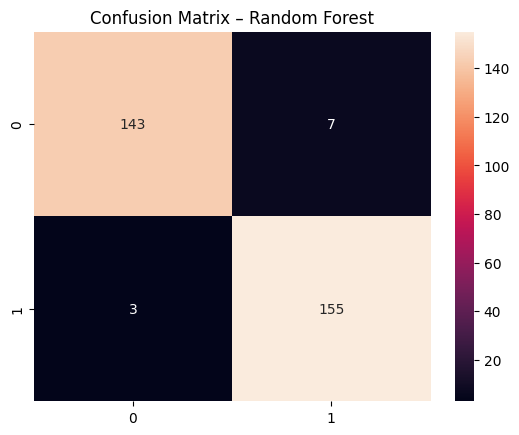

In [ ]:
# Step 4: Random Forest Classifier with Hyperparameter Tuning
# RandomizedSearchCV performs random hyperparameter tuning to find the best model settings efficiently.
# KFold provides cross-validation by splitting the data into multiple folds to ensure more reliable model evaluation.
# randint and uniform used to define random distributions for hyperparameters like tree depth or learning features.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Build a pipeline: Preprocessing → Random Forest Classifier
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Define hyperparameter search space
param_dist = {
    "classifier__n_estimators": randint(200, 800), # Number of trees in the forest
    "classifier__max_depth": randint(5, 30), # Maximum depth of each tree
    "classifier__max_features": uniform(0.3, 0.7), # Fraction of features used when splitting
    "classifier__min_samples_split": randint(2, 12), # Minimum samples to split a node
    "classifier__min_samples_leaf": randint(1, 6) # Minimum samples at a leaf node
}

# Use K-Fold Cross-Validation for robust evaluation
cv = KFold(n_splits=4, shuffle=True, random_state=42)

# Perform randomized search over hyperparameters (optimize F1-score)
search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist,
    n_iter=25, cv=cv, scoring="f1", n_jobs=-1, verbose=2, random_state=42
)
search.fit(X_train, y_train)

# Extract the best model
best_rf = search.best_estimator_
print("Best RF Params:", search.best_params_)

# Evaluate Random Forest performance
y_pred = best_rf.predict(X_valid)
acc = accuracy_score(y_valid, y_pred)
prec = precision_score(y_valid, y_pred)
rec = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)
print(f"RF | Accuracy:{acc:.4f} Precision:{prec:.4f} Recall:{rec:.4f} F1:{f1:.4f}")

# Confusion matrix visualization
sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix – Random Forest")
plt.show()
# 143 true negatives and 155 true positives  the model achieved higher accuracy with only few false positives and false negatives.

C:\Users\yenya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7183 - loss: 0.5747 - val_accuracy: 0.8377 - val_loss: 0.4454
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8368 - loss: 0.4165 - val_accuracy: 0.8344 - val_loss: 0.3616
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8494 - loss: 0.3690 - val_accuracy: 0.8409 - val_loss: 0.3410
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8591 - loss: 0.3473 - val_accuracy: 0.8539 - val_loss: 0.3348
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8773 - loss: 0.3228 - val_accuracy: 0.8506 - val_loss: 0.3298
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8731 - loss: 0.3054 - val_accuracy: 0.8539 - val_loss: 0.3240
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8759 - loss: 0.2989 - val_accuracy: 0.8701 - val_loss: 0.3162
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8801 - loss: 0.2892 - val_accuracy: 0.8669 - 

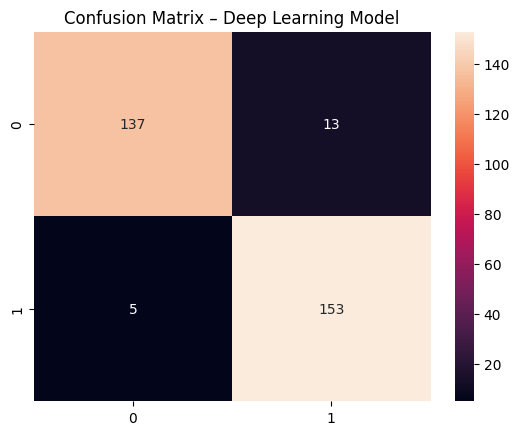

In [13]:
# Step 5: Deep Learning Model (MLP)
# Sequential defines the neural network as a sequence of layers.
# Dense creates fully connected layers where every neuron is connected to all neurons in the previous layer.
# Dropout helps prevent overfitting by randomly turning off some neurons during training.
# Early Stopping monitors the validation loss and automatically stops training when the model stops improving, saves time, prevents overfitting.
# classification_report generates detailed evaluation metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# Preprocess data (convert all features to numeric matrix)
X_train_all = preprocessor.fit_transform(X_train)
X_valid_all = preprocessor.transform(X_valid)

# Define MLP architecture
# used two hidden layers with ReLU activation because it helps the network learn nonlinear patterns efficiently.
# The output layer uses Sigmoid since it’s a binary classification problem.
# used the Adam optimizer for faster and more stable convergence, and binary cross-entropy as the loss function 
# because it’s suitable for binary outcomes.
input_dim = X_train_all.shape[1]
model_dl = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Binary output
])

# Compile model with binary cross-entropy loss
model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Add early stopping to prevent overfitting (Help to improve model generalization)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model_dl.fit(
    X_train_all, y_train,
    validation_data=(X_valid_all, y_valid),
    epochs=100, batch_size=32, callbacks=[es], verbose=1
)

# --- Evaluate Deep Learning model
y_pred_prob = model_dl.predict(X_valid_all).ravel()
y_pred_dl = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_valid, y_pred_dl))
sns.heatmap(confusion_matrix(y_valid, y_pred_dl), annot=True, fmt='d')
plt.title("Confusion Matrix – Deep Learning Model")
plt.show()


In [14]:
# Step 6: Model Comparison Table
comparison = pd.DataFrame({
    "Model": ["Random Forest Classifier", "Neural Network (MLP)"],
    "Type": ["Traditional ML", "Deep Learning"],
    "Accuracy": [acc, model_dl.evaluate(X_valid_all, y_valid, verbose=0)[1]],
    "Precision": [prec, precision_score(y_valid, y_pred_dl)],
    "Recall": [rec, recall_score(y_valid, y_pred_dl)],
    "F1": [f1, f1_score(y_valid, y_pred_dl)]
})
display(comparison)


,Model,Type,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,Traditional ML,0.967532,0.956790,0.981013,0.968750
1,Neural Network (MLP),Deep Learning,0.941558,0.921687,0.968354,0.944444


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


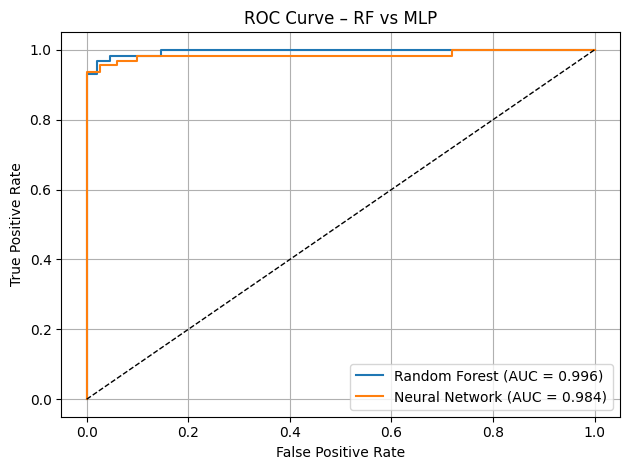

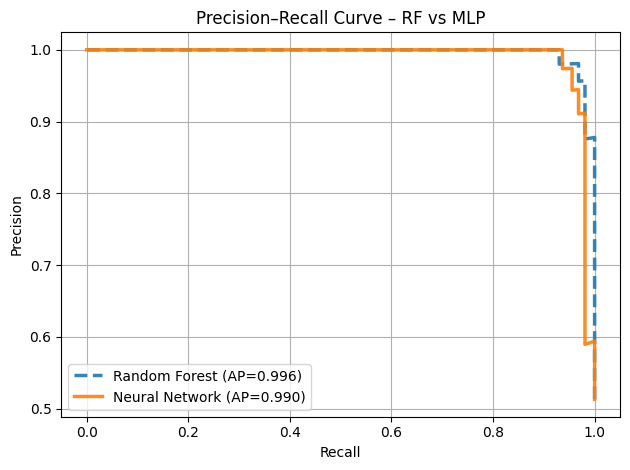

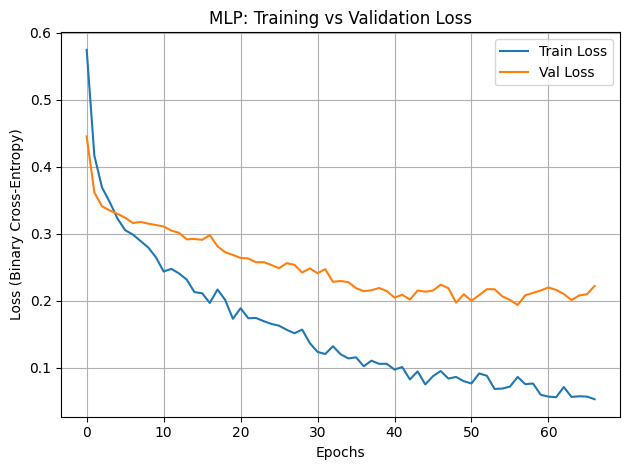

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Step 7: Performance Visualization (ROC, PR Curves, Loss) (Receiver Operating Characteristic Curve, Precision Recall Curve, Area Under Curve)
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
import seaborn as sns
import pandas as pd

# === ROC Curve: RF vs MLP ===
# Probability score (positive class = 1)
y_prob_rf  = best_rf.predict_proba(X_valid)[:, 1]      
y_prob_dl  = model_dl.predict(X_valid_all).ravel()     

# Calculate ROC
fpr_rf, tpr_rf, _ = roc_curve(y_valid, y_prob_rf)
fpr_dl, tpr_dl, _ = roc_curve(y_valid, y_prob_dl)
auc_rf = auc(fpr_rf, tpr_rf)
auc_dl = auc(fpr_dl, tpr_dl)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_dl, tpr_dl, label=f"Neural Network (AUC = {auc_dl:.3f})")
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – RF vs MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/cls_roc_rf_vs_mlp.png", dpi=150)
plt.show()

# === Precision–Recall Curve: RF vs MLP ===
prec_rf, rec_rf, _ = precision_recall_curve(y_valid, y_prob_rf)
prec_dl, rec_dl, _ = precision_recall_curve(y_valid, y_prob_dl)
ap_rf = average_precision_score(y_valid, y_prob_rf)
ap_dl = average_precision_score(y_valid, y_prob_dl)

plt.figure()
plt.plot(rec_rf, prec_rf, '--',  linewidth=2.5, alpha=0.9, label=f"Random Forest (AP={ap_rf:.3f})", zorder=2)
plt.plot(rec_dl, prec_dl, '-',   linewidth=2.5, alpha=0.9, label=f"Neural Network (AP={ap_dl:.3f})", zorder=3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – RF vs MLP")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.savefig("images/cls_pr_rf_vs_mlp.png", dpi=150)
plt.show()

# === MLP: Training vs Validation Loss ===
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("MLP: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/cls_mlp_loss.png", dpi=150)
plt.show()


🔧 Hybrid best weight (RF weight) = 0.60
Hybrid | Accuracy:0.9773 Precision:0.9748 Recall:0.9810 F1:0.9779


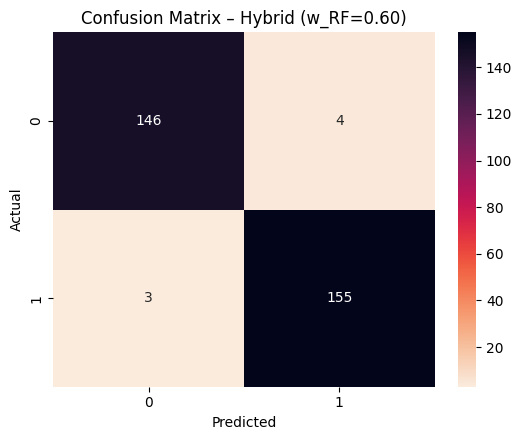

,Model,Type,Accuracy,Precision,Recall,F1
0,Random Forest Classifier,Traditional ML,0.967532,0.956790,0.981013,0.968750
1,Neural Network (MLP),Deep Learning,0.941558,0.921687,0.968354,0.944444
2,Hybrid (w_RF=0.60 · RF + 0.40 · MLP),Ensemble,0.977273,0.974843,0.981013,0.977918


In [16]:
# =========================
# Hybrid Model: Weighted Average of RF & MLP
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# 1) Take the positive class probability of each model
try:
    y_prob_rf
    y_prob_dl
except NameError:
    # RF probability: predict the original X_valid directly on the pipeline
    y_prob_rf = best_rf.predict_proba(X_valid)[:, 1]
    # MLP Probability: Prediction of a Dense Matrix (Preprocessed)
    y_prob_dl = model_dl.predict(X_valid_all).ravel()

# Combine model predictions using weighted average
weights = np.linspace(0, 1, 21)  # from 0.00, 0.05, ..., to 1.00
best = {"w": None, "f1": -1, "acc": None, "prec": None, "rec": None}

# Search for best weight that maximizes F1-score
for w in weights:
    y_prob_h = w * y_prob_rf + (1 - w) * y_prob_dl
    y_pred_h = (y_prob_h > 0.5).astype(int)

    f1  = f1_score(y_valid, y_pred_h)
    acc = accuracy_score(y_valid, y_pred_h)
    pre = precision_score(y_valid, y_pred_h)
    rec = recall_score(y_valid, y_pred_h)

    if f1 > best["f1"]:
        best.update({"w": w, "f1": f1, "acc": acc, "prec": pre, "rec": rec})

print(f"🔧 Hybrid best weight (RF weight) = {best['w']:.2f}")
print(f"Hybrid | Accuracy:{best['acc']:.4f} Precision:{best['prec']:.4f} "
      f"Recall:{best['rec']:.4f} F1:{best['f1']:.4f}")

# 3)Generate final predictions using the optimal weights and plot the confusion matrix
y_prob_hybrid = best["w"] * y_prob_rf + (1 - best["w"]) * y_prob_dl
y_pred_hybrid = (y_prob_hybrid > 0.5).astype(int)

# Plot confusion matrix for hybrid model
cm = confusion_matrix(y_valid, y_pred_hybrid)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=True)
plt.title(f"Confusion Matrix – Hybrid (w_RF={best['w']:.2f})")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("images/cls_cm_hybrid.png", dpi=150)
plt.show()

# 4) Append hybrid results to comparison table
row = {
    "Model": f"Hybrid (w_RF={best['w']:.2f} · RF + {1-best['w']:.2f} · MLP)",
    "Type": "Ensemble",
    "Accuracy": best["acc"],
    "Precision": best["prec"],
    "Recall": best["rec"],
    "F1": best["f1"]
}

try:
    comparison = pd.concat([comparison, pd.DataFrame([row])], ignore_index=True)
except NameError:
    comparison = pd.DataFrame([row])

display(comparison)
